<p style="font-size: 20px;">
<b>Student Full Name:</b> Jasser Dhaouadi </br>
<b>Student ID:</b> U89818600 </br>
<b>Course:</b> AI For Leaders - 2 </br>
<b>Semester:</b> Spring 2026 </br>
<b>Program:</b> OMDS </br>
<b>Boston University</b> 
</p>

# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

### Answer:  [Dataset: CDC Diabetes Health Indicators  (sourced from BRFSS)]

- **Who** 
    - Public health officials or healthcare administrators who make prevention and resource allocation decisions.

- **What**
    - Diabetes risk increases with factors like high blood pressure, higher BMI, older age, and poorer general health, showing a clear progression from no diabetes to prediabetes to diabetes. 
    - Early intervention opportunities exist.

- **How**
    - We can use simple and focused visuals <u>to clearly highlight risk patterns and support targeted prevention strategies</u>
    - The visuals should guide attention to the strongest patterns
    - Visuals examples: 
        - class distribution bars
        - side-by-side comparisons (e.g., HighBP by diabetes status)
        - boxplots of BMI and Age 


# 3. Homework - work with your own data

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

### Answer:

## Dataset: CDC Diabetes Health Indicators  (sourced from BRFSS) 

## EDA 

In [2]:
# Read the diabetes dataset
dataset_path = "data/diabetes_012_health_indicators_BRFSS2015.csv"
df_diabetes = pd.read_csv(dataset_path)

In [3]:
# Dataset Shape 
rows_nbr = df_diabetes.shape[0]
cols_nbr = df_diabetes.shape[1]

print("Total rows: {}. Total columns: {}.".format(rows_nbr, cols_nbr))


Total rows: 253680. Total columns: 22.


#### *1- Shape of the Dataset*

* 253,680 rows
* 22 columns (21 features + 1 target: Diabetes_012)

In [4]:
# info() summary
df_diabetes.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [5]:
# Calculate missing values per column
missing_counts = df_diabetes.isnull().sum()
missing_counts

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

#### *2- Dataset Overview*

* All columns are numeric

* Dataset is clean from a datatype perspective

* No missing values detected -> **No imputation required**


In [6]:
print("Column names:")
print(df_diabetes.columns.to_list())

Column names:
['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [7]:
df_diabetes.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


#### *3- Descriptive Statistics Overview*

* Most variables are binary (0/1) or ordinal categories

* The feature BMI is continuous

* the target variable Diabetes_012 ranges from 0 to 2 (3-class target)


#### *4- Variables Table*

| Variable Name | Role | Type | Description |
| --- | --- | --- | --- |
| Diabetes_012 | Target | Integer | 0 is for no diabetes or only during pregnancy </br> 1 is for prediabetes </br> 2 is for diabetes |
| HighBP | Feature | Binary | 0 = no high BP </br> 1 = high BP </br> [BP: Blood Pressure]|
| HighChol | Feature | Binary | 0 = no high cholesterol </br> 1 = high cholesterol|
| CholCheck | Feature | Binary | 0 = no cholesterol check in 5 years </br> 1 = yes cholesterol check in 5 years|
| BMI | Feature | Integer/Continuous | Body Mass Index|
| Smoker | Feature | Binary | Have you smoked at least 100 cigarettes in your entire life? </br> [Note: 5 packs = 100 cigarettes] </br> 0 = no </br> 1 = yes|
| Stroke | Feature | Binary | (Ever told) you had a stroke? </br> 0 = no </br> 1 = yes|
| HeartDiseaseorAttack | Feature | Binary | coronary heart disease (CHD) or myocardial infarction (MI) </br> 0 = no </br> 1 = yes|
| PhysActivity | Feature | Binary | physical activity in past 30 days - not including job </br> 0 = no </br> 1 = yes|
| Fruits | Feature | Binary | Consume Fruit 1 or more times per day </br> 0 = no </br> 1 = yes|
| Veggies | Feature | Binary | Consume Vegetables 1 or more times per day </br> 0 = no </br> 1 = yes|
| HvyAlcoholConsump | Feature | Binary | Heavy drinkers (adult men having more than 14 drinks per week and </br> adult women having more than 7 drinks per week) </br> 0 = no </br> 1 = yes|
| AnyHealthcare | Feature | Binary | Have any kind of health care coverage, </br> including health insurance, </br> prepaid plans such as HMO, etc. </br> 0 = no </br> 1 = yes|
| NoDocbcCost | Feature | Binary | Was there a time in the past 12 months </br> when you needed to see a doctor </br> but could not because of cost? </br> 0 = no </br> 1 = y|
| GenHlth | Feature | Integer | Would you say that in general your health is: scale 1-5 </br> 1 = excellent </br> 2 = very good </br> 3 = good </br> 4 = fair </br> 5 = poor|
| MentHlth | Feature | Integer | Now thinking about your mental health, </br> which includes stress, depression, and problems with emotions, </br> for how many days during the past 30 days was your mental health not good? </br> scale 1-30 days|
| PhysHlth | Feature | Integer | Now thinking about your physical health, </br> which includes physical illness and injury, </br> for how many days during the past 30 days was your physical health not good? </br> scale 1-30 days|
| DiffWalk | Feature | Binary | Do you have serious difficulty walking or climbing stairs? </br>  0 = no </br>  1 = yes|
| Sex | Feature | Binary | 0 = female </br> 1 = male|
| Age | Feature | Integer | 13-level age category (_AGEG5YR see codebook) </br> 1 = 18-24 / 9 = 60-64 / 13 = 80 or older|
| Education | Feature | Integer | Education level (EDUCA see codebook) scale 1-6 </br> 1 = Never attended school or only kindergarten </br> 2 = (Elementary) </br> 3 = (Some high school) </br> 4 = (High school graduate) </br> 5 = (Some college or technical school) </br> 6 = (College graduate)|
| Income | Feature | Integer | 	Income scale (INCOME2 see codebook) scale 1-8 </br> 1 = less than $10,000 </br> 5 = less than $35,000 </br> 8 = $75,000 or more|

#### *5- Duplicate Data Check*

In [8]:
# Check: Duplicate rows
duplicate_rows_count = df_diabetes.duplicated().sum()

# Check: Duplicate values per column
duplicate_values_per_column = {col: df_diabetes[col].duplicated().sum() for col in df_diabetes.columns}

print("Duplicate Rows Count:")
print(duplicate_rows_count)
print("--------------------------------")
print("Duplicate Values Per Column:")
for k,v in duplicate_values_per_column.items():
    print(f"{k} : {int(v)}")

Duplicate Rows Count:
23899
--------------------------------
Duplicate Values Per Column:
Diabetes_012 : 253677
HighBP : 253678
HighChol : 253678
CholCheck : 253678
BMI : 253596
Smoker : 253678
Stroke : 253678
HeartDiseaseorAttack : 253678
PhysActivity : 253678
Fruits : 253678
Veggies : 253678
HvyAlcoholConsump : 253678
AnyHealthcare : 253678
NoDocbcCost : 253678
GenHlth : 253675
MentHlth : 253649
PhysHlth : 253649
DiffWalk : 253678
Sex : 253678
Age : 253667
Education : 253674
Income : 253672


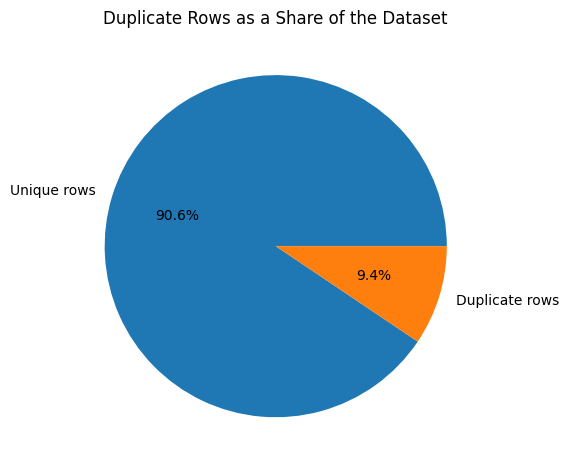

In [9]:
# Pie chart 
plt.figure()
plt.pie([int(rows_nbr - duplicate_rows_count), int(duplicate_rows_count)], labels=["Unique rows", "Duplicate rows"], autopct="%1.1f%%")
plt.title("Duplicate Rows as a Share of the Dataset")
plt.tight_layout()
plt.show()

#### *Interpretation*
- **Duplicate Rows**: </br>
    - 23,899 duplicate rows found. This is significant (approx 9.4% of the dataset)
    - **Decision**:</br>
    The duplicate rows should be **kept** because this dataset originates from the BRFSS survey, where identical rows most likely represent different individuals who gave the same responses. </br> Removing them would distort the true population distribution  and introduce bias into any statistical analysis or machine learning model built from the data.

- **Duplicate Values in Columns**: </br>
    - Every column contains duplicate values, which is **expected and valid**, because this is a survey: (each column is binary or representing ordinal categories and BMI feature can be the same across different individuals)



#### *6- Central Tendency and Distributions*

In [10]:
central_tendency = pd.DataFrame({
    "mean": df_diabetes.mean(),
    "median": df_diabetes.median(),
    "mode": df_diabetes.mode().iloc[0]
})

central_tendency

,mean,median,mode
Diabetes_012,0.296921,0.0,0.0
HighBP,0.429001,0.0,0.0
HighChol,0.424121,0.0,0.0
CholCheck,0.962670,1.0,1.0
BMI,28.382364,27.0,27.0
Smoker,0.443169,0.0,0.0
Stroke,0.040571,0.0,0.0
HeartDiseaseorAttack,0.094186,0.0,0.0
PhysActivity,0.756544,1.0,1.0
Fruits,0.634256,1.0,1.0


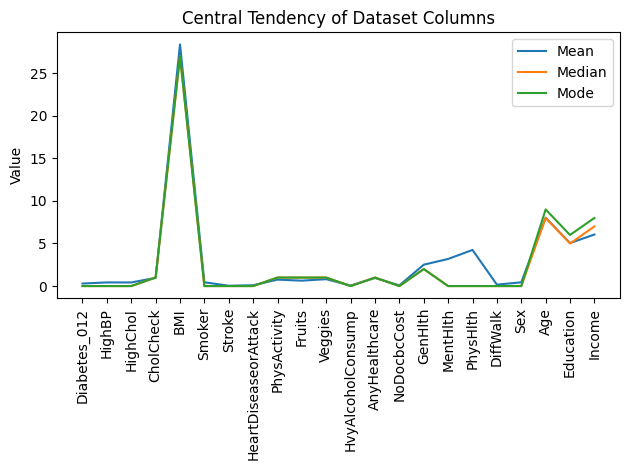

In [11]:
# Calculate central tendency
means = df_diabetes.mean()
medians = df_diabetes.median()
modes = df_diabetes.mode().iloc[0]

# Plot (single plot, no explicit colors)
plt.figure()
plt.plot(means.values, label="Mean")
plt.plot(medians.values, label="Median")
plt.plot(modes.values, label="Mode")

plt.xticks(range(len(df_diabetes.columns)), df_diabetes.columns, rotation=90)
plt.title("Central Tendency of Dataset Columns")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

#### *Interpretation*
- Most **binary variables** show very close mean, median, and mode values
- **BMI** stands out with a much larger scale compared to other variables.
    - Mean > median typically suggests mild right skew (expected in BMI distributions)
- **Ordinal variables** like <u>Age, Education, and Income</u> show slight variation between mean and median, indicating mild skewness.
- For many categorical/binary features, <u>the mode is 0 (majority class)</u>, which aligns with expectations.
- For **Diabetes_012** (target variable)
    - Mean gives rough indication of class distribution
    - Mode is likely 0 (majority class)

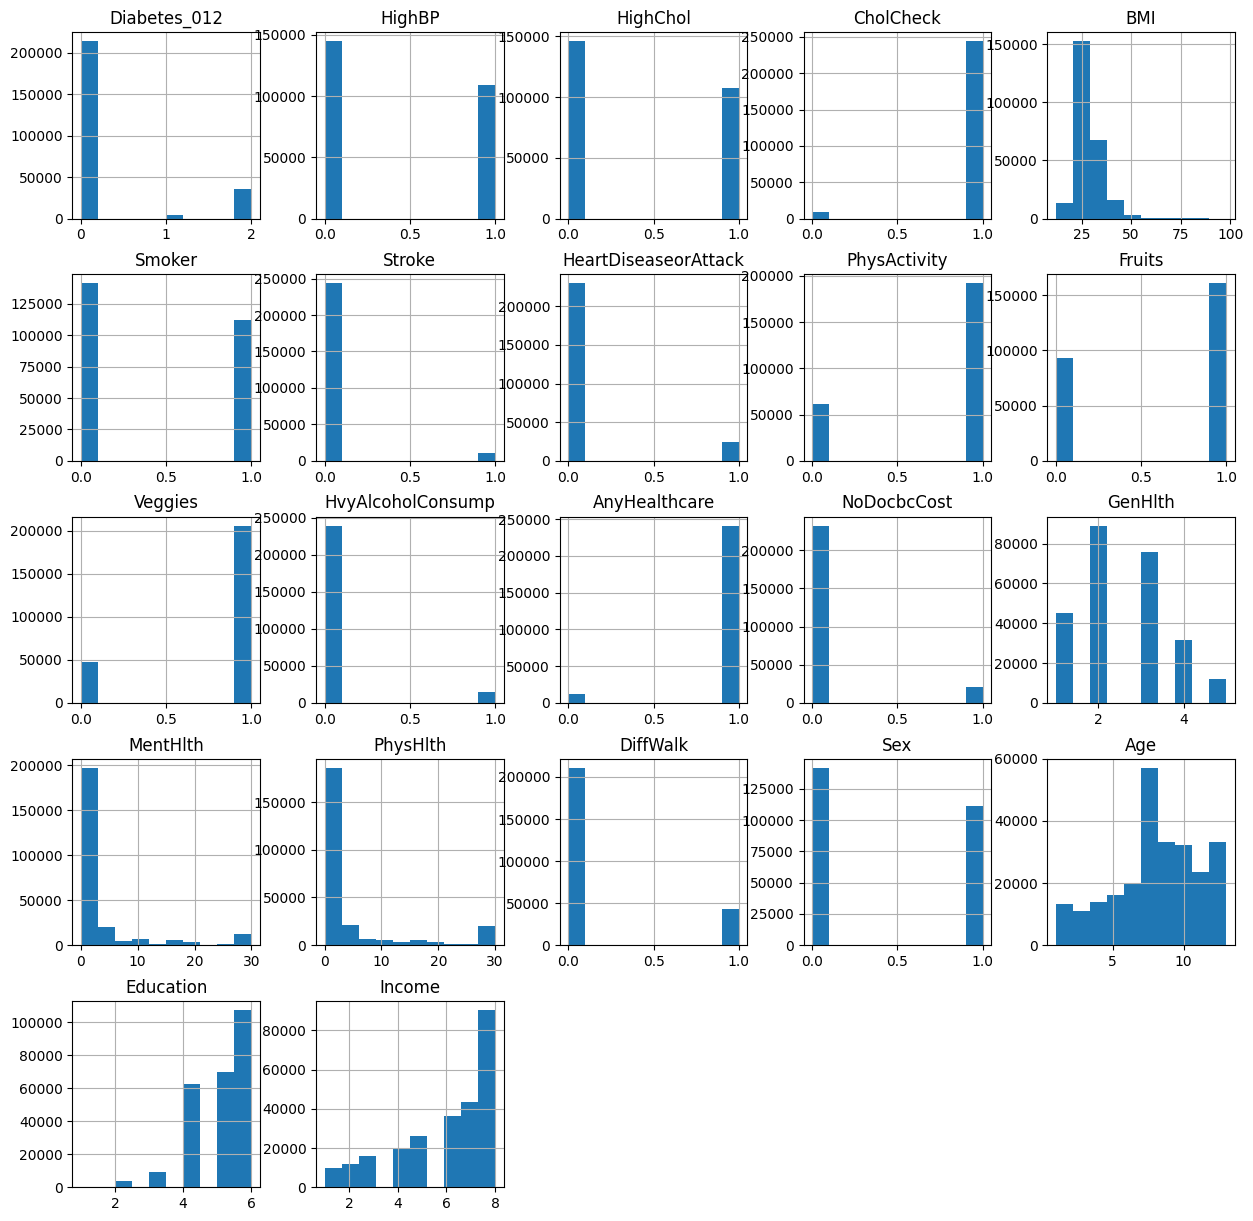

In [12]:
df_diabetes.hist(figsize=(15, 15));

- **Overall Distribution Characteristics**
    - Majority of features are binary or ordinal.
    - Very few normally distributed variables.
    - Several strong right-skewed features (BMI, MentHlth, PhysHlth).
    - Significant imbalance in target and several predictors.

#### *7- Inconsistent Data Checks*

In [13]:
invalid_bmi_count = (df_diabetes["BMI"] <= 0).sum()
invalid_age_count = (~df_diabetes["Age"].between(1, 13)).sum()

print(f"invalid_bmi_count: {int(invalid_bmi_count)}")
print(f"invalid_age_count: {int(invalid_age_count)}")

invalid_bmi_count: 0
invalid_age_count: 0


- **BMI**
    - No BMI ≤ 0 values
    - No invalid BMI detected
- **Age**
    - All values between 1 and 13 (correct BRFSS categorical encoding)

- **Conclusion** 
    - Dataset appears clean
    - No detected issues like:
        - Negative values
        - Impossible ranges 
        - Out-of-bound categorical codes


#### *8- Encoding Categorical Variables*

- No need to apply additional encoding to the categorical variables because this dataset is already numerically encoded
- Most categorical features are stored in binary or ordinal numeric form, making them directly usable for statistical analysis and machine learning models
    - **HighBP, HighChol, Smoker, Stroke, PhysActivity** are already binary (0 = No, 1 = Yes).
    - **Sex** is encoded as 0 and 1.
    - **Age, Education, Income, GenHlth** are ordinal categories represented as integers (e.g., Age ranges from 1–13 corresponding to age groups).

#### *9- Important: Class Imbalance (Target)*

Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64


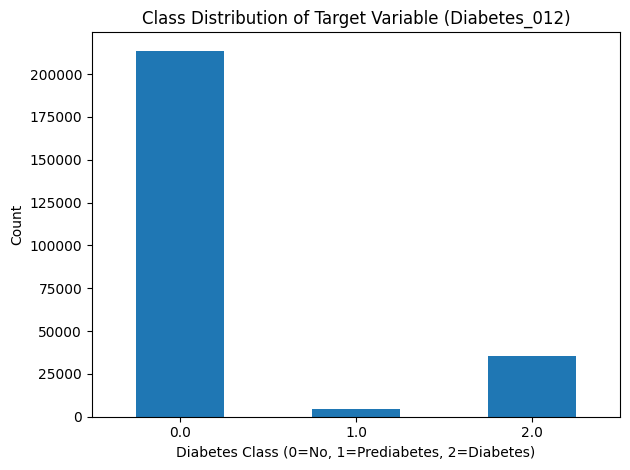

In [14]:
class_counts = df_diabetes["Diabetes_012"].value_counts().sort_index()
print(class_counts)

# Create bar plot
plt.figure()
class_counts.plot(kind='bar')
plt.title("Class Distribution of Target Variable (Diabetes_012)")
plt.xlabel("Diabetes Class (0=No, 1=Prediabetes, 2=Diabetes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- **Class distribution**
    - Class 0 (No diabetes): 213,703
    - Class 1 (Prediabetes): 4,631
    - Class 2 (Diabetes): 35,346


- **This confirms severe class imbalance, especially for the prediabetes class**:
    - Class 0 dominates the dataset (~84%)
    - Class 2 represents ~14%
    - Class 1 is extremely underrepresented (~1.8%)


- **Possible Implications for Modeling**
    - Accuracy alone will be misleading.
    - The model may ignore Class 1 (Prediabetes)

#### *10- Feature Distribution Analysis by Diabetes Class*

We analyzed 3 key features: **BMI, Age, and GenHlth** across the 3 target classes (0 = No diabetes, 1 = Prediabetes, 2 = Diabetes).

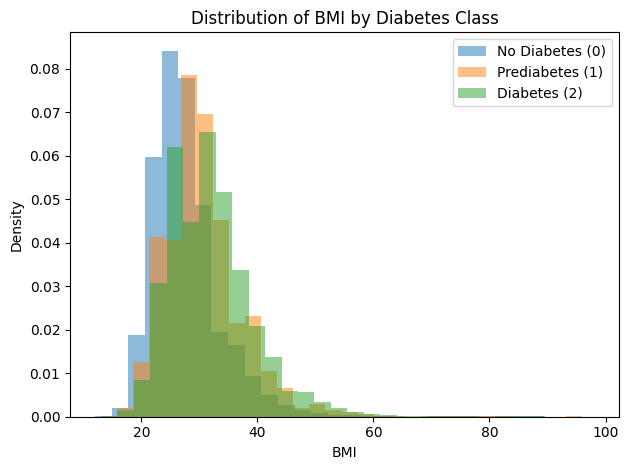

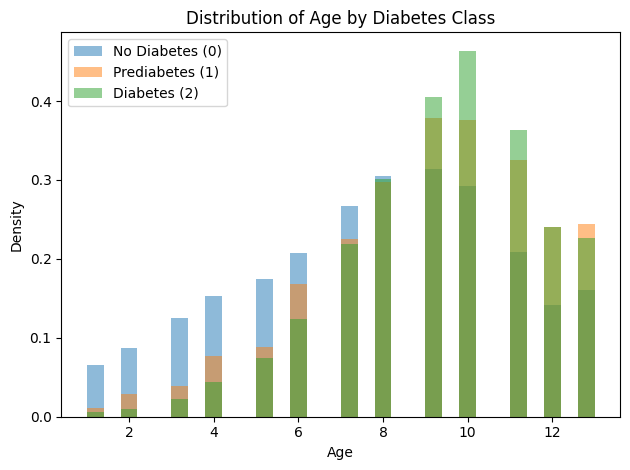

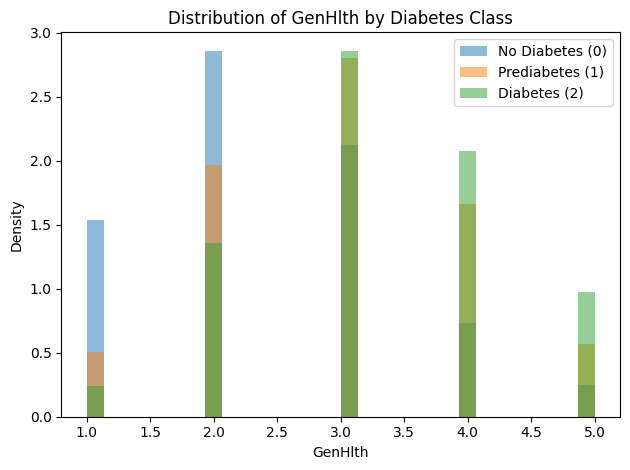

In [15]:
features = ["BMI", "Age", "GenHlth"]

class_labels = {
    0: "No Diabetes (0)",
    1: "Prediabetes (1)",
    2: "Diabetes (2)"
}

for feature in features:
    plt.figure()
    
    for cls in sorted(df_diabetes["Diabetes_012"].unique()):
        subset = df_diabetes[df_diabetes["Diabetes_012"] == cls][feature]
        plt.hist(subset, bins=30, alpha=0.5, density=True, label=class_labels[cls])
    
    plt.title(f"Distribution of {feature} by Diabetes Class")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

#### *Interpretation*

- **BMI**
    - The BMI distribution shifts to the right as we move from: Class 0 -> Class 1 -> Class 2
    - Individuals with diabetes tend to have higher BMI values
    - BMI appears to be a strong predictive feature


- **Age**:
    - Class 2 (Diabetes) is more concentrated in higher age categories
    - Class 0 has more representation in younger groups
    - Prediabetes sits between the two
    - Age shows a clear increasing trend with diabetes prevalence


- **General Health (GenHlth)**
    - Diabetes group reports worse general health (values closer to 4–5)
    - Non-diabetes group reports better health (1–2)
    - Clear separation trend visible

#### *11- Final Conclusions*
- **Are the data usable?**
    - Yes. The dataset is clean, complete, and properly encoded, making it suitable for analysis and modeling.

- **Do you need to modify or correct the data?**
    - No major corrections are needed. Only standard preprocessing (e.g., scaling and imbalance handling) may be required for modeling.

- **Is there any class imbalance?**
    - Yes. The target variable is highly imbalanced, with Class 0 dominating and Class 1 severely underrepresented.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

### Answer:
The graph selected for reproduction on the diabetes dataset is **Figure 0.4 (Pie Chart) from page 5 of the book (Introduction of Storytelling With Data)**.

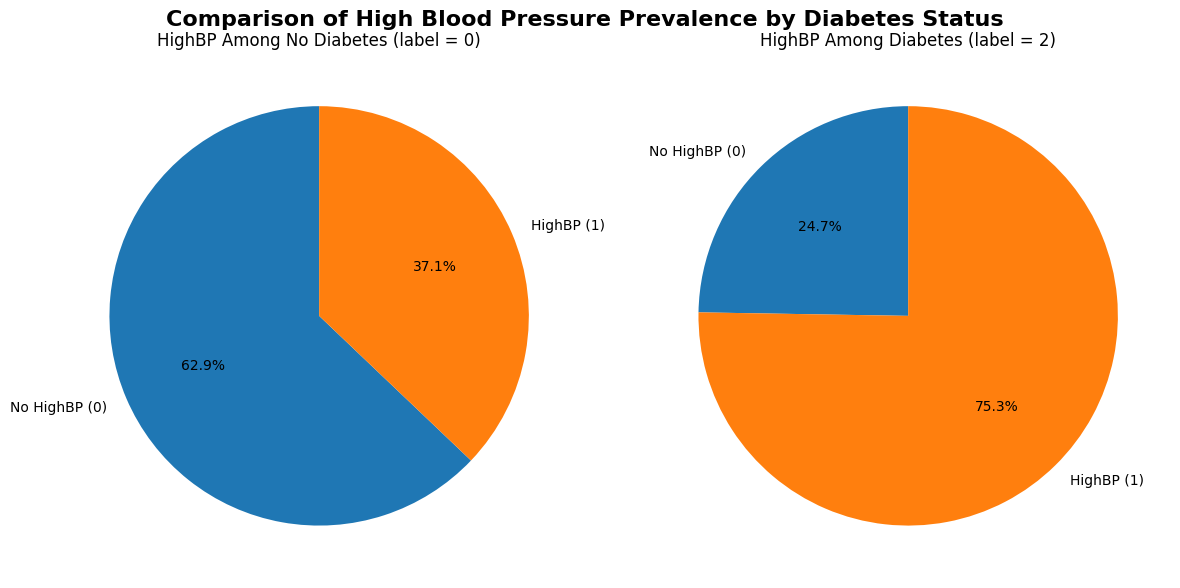

In [16]:
# Data preparation
no_diabetes = df_diabetes[df_diabetes["Diabetes_012"] == 0]["HighBP"].value_counts().sort_index()
diabetes = df_diabetes[df_diabetes["Diabetes_012"] == 2]["HighBP"].value_counts().sort_index()

labels = ["No HighBP (0)", "HighBP (1)"]

# Create side-by-side pie charts
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# Add main comparison title
fig.suptitle("Comparison of High Blood Pressure Prevalence by Diabetes Status", fontsize=16, fontweight="bold")

# Left pie
axes[0].pie(no_diabetes.values, labels=labels, autopct="%1.1f%%", startangle=90)
axes[0].set_title("HighBP Among No Diabetes (label = 0)")

# Right pie
axes[1].pie(diabetes.values, labels=labels, autopct="%1.1f%%", startangle=90)
axes[1].set_title("HighBP Among Diabetes (label = 2)")

#plt.title("High Blood Pressure Distribution: No Diabetes vs. Diabetes")
plt.tight_layout()
plt.show()